##### Copyright 2026 Google LLC.

Shortest Path: ['S', 'B', 'C', 'D']
Total Cost: 7


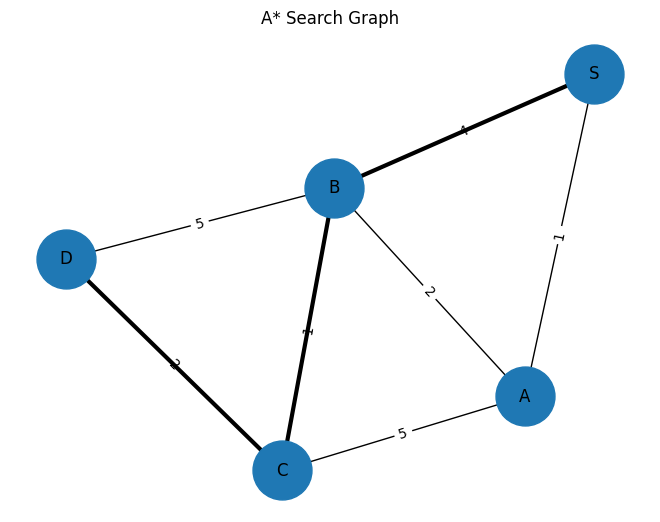

In [2]:
# ============================================================
# AI Assignment 2: A* Search Algorithm (Modified Version)
# ============================================================

import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Graph (node names changed)
graph_map = {
    'S': [('A', 1), ('B', 4)],
    'A': [('S', 1), ('B', 2), ('C', 5)],
    'B': [('S', 4), ('A', 2), ('C', 1), ('D', 5)],
    'C': [('A', 5), ('B', 1), ('D', 2)],
    'D': [('B', 5), ('C', 2)]
}

# Heuristic values
h_values = {
    'S': 7,
    'A': 6,
    'B': 2,
    'C': 1,
    'D': 0
}

# ---------------- A* FUNCTION ----------------
def astar_search(g, h, start_node, goal_node):
    priority_queue = [(h[start_node], 0, start_node, [start_node])]
    visited_nodes = set()

    while priority_queue:
        f_cost, g_cost, current_node, path = heapq.heappop(priority_queue)

        if current_node in visited_nodes:
            continue

        if current_node == goal_node:
            return path, g_cost

        visited_nodes.add(current_node)

        for next_node, weight in g[current_node]:
            if next_node not in visited_nodes:
                new_g = g_cost + weight
                new_f = new_g + h[next_node]
                heapq.heappush(priority_queue, (new_f, new_g, next_node, path + [next_node]))

    return None, float('inf')

# ---------------- GRAPH DRAW ----------------
def display_graph(g, path=None):
    G = nx.Graph()

    for node in g:
        for neighbour, weight in g[node]:
            G.add_edge(node, neighbour, weight=weight)

    pos = nx.spring_layout(G)

    nx.draw(G, pos, with_labels=True, node_size=1800)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path:
        edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edges, width=3)

    plt.title("A* Search Graph")
    plt.show()

# ---------------- MAIN ----------------
if __name__ == "__main__":
    start = 'S'
    goal = 'D'

    final_path, total_cost = astar_search(graph_map, h_values, start, goal)

    print("Shortest Path:", final_path)
    print("Total Cost:", total_cost)

    display_graph(graph_map, final_path)